# Delivery SLA Performance & Geographic Delay Analysis

**Business question:** What proportion of deliveries miss their SLA estimate, and which geographies carry the highest delay risk?

**Decisions supported:**
- Carrier contract negotiation and regional logistics partner review
- Customer-facing ETA calibration
- Proactive delay communication policy


## Data Sources

| Query | Description | Grain |
|---|---|---|
| Q1: National SLA summary | `vw_delivery_sla_metrics` + `customers` | One row (national totals) |
| Q2: Delay by state | `vw_delivery_sla_metrics` + `customers` | One row per customer state |

**Key columns used:** `total_deliveries`, `total_delayed_orders`, `delayed_rate_pct`, `avg_actual_delivery_days`, `avg_estimated_delivery_days`, `customer_state`, `delayed_orders`, `avg_delay_days_when_delayed`

**Filter:** `vw_delivery_sla_metrics` excludes cancelled and unavailable orders by definition. Only orders with non-null actual delivery timestamps are included.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

_REPO_ROOT = Path().resolve().parents[1]
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from analysis.utils.db import get_connection
from analysis.utils.sql_loader import get_sql_path, load_queries
from analysis.utils.plotting import apply_style, save_figure

apply_style()

# Load SQL queries
sql_path = get_sql_path("sql/analysis/03_delivery_sla_performance.sql")
queries = load_queries(sql_path)

# Execute both SLA queries
with get_connection() as conn:
    df_sla_summary = pd.read_sql(queries[0], conn)
    df_delay_state = pd.read_sql(queries[1], conn)

_checks_03 = [
    ("SLA summary row returned",          len(df_sla_summary) == 1),
    ("Delay state rows > 0",             len(df_delay_state) > 0),
    ("Delay rate 0-100",                 df_delay_state["delayed_rate_pct"].between(0, 100).all()),
    ("Total deliveries > 0",             int(df_sla_summary["total_deliveries"].iloc[0]) > 0),
]
print("Notebook 03 — Data Validation")
for label, passed in _checks_03:
    print(f"  [{'PASS' if passed else 'FAIL'}]  {label}")

print()
display(df_sla_summary)
display(df_delay_state.head(15))


Notebook 03 — Data Validation
  [PASS]  SLA summary row returned
  [PASS]  Delay state rows > 0
  [PASS]  Delay rate 0-100
  [PASS]  Total deliveries > 0



/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_61410/3625710528.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sla_summary = pd.read_sql(queries[0], conn)
/var/folders/f2/83l3tcxd02d7x40w9_lwqz5m0000gn/T/ipykernel_61410/3625710528.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_delay_state = pd.read_sql(queries[1], conn)


,total_deliveries,total_delayed_orders,delayed_rate_pct,avg_actual_delivery_days,avg_estimated_delivery_days
0,96478,7826,8.11,12.558217,23.736347


,customer_state,total_deliveries,delayed_orders,delayed_rate_pct,avg_delay_days_when_delayed
0,AL,397,95,23.93,9.246130
1,MA,717,141,19.67,9.970709
2,PI,476,76,15.97,12.298219
3,CE,1279,196,15.32,14.326787
4,SE,335,51,15.22,16.890978
5,BA,3256,457,14.04,11.099223
6,RJ,12350,1664,13.47,12.848692
7,TO,274,35,12.77,5.651584
8,PA,946,117,12.37,12.303485
9,ES,1995,244,12.23,10.596163


## Analytical Methodology

**Methods applied:**
- **Donut chart** (panel A): the hollow centre is used for a summary KPI label (overall delayed %). Donut charts are appropriate for a single proportion comparison — on-time vs. delayed.
- **Bar chart with benchmark** (panel B): actual vs. estimated delivery days shown as side-by-side bars with a gap annotation. This directly quantifies the ETA calibration error.
- **KPI scorecard** (panel C): a text layout for 6 scalar KPIs that don't lend themselves to chart encoding. Used to anchor the executive at a glance before regional detail.
- **Full-state bar chart** (panel D): all states shown in a single chart, colour-coded against the national average. Allows immediate identification of above/below-average states.
- **Horizontal bar** (panel E): absolute delayed order counts for the worst-rate states. Separates the rate analysis from the volume analysis.
- **Bubble scatter** (panel F): delivery volume vs. delay rate, with bubble size encoding absolute delayed count. This 3-variable encoding identifies the true high-impact states.

**Why this method:** SLA analysis is fundamentally about rates and volumes across two dimensions (time and geography). The combination of rate analysis (panel D) and absolute volume analysis (panel E) is necessary because high-rate and high-volume states require different interventions.


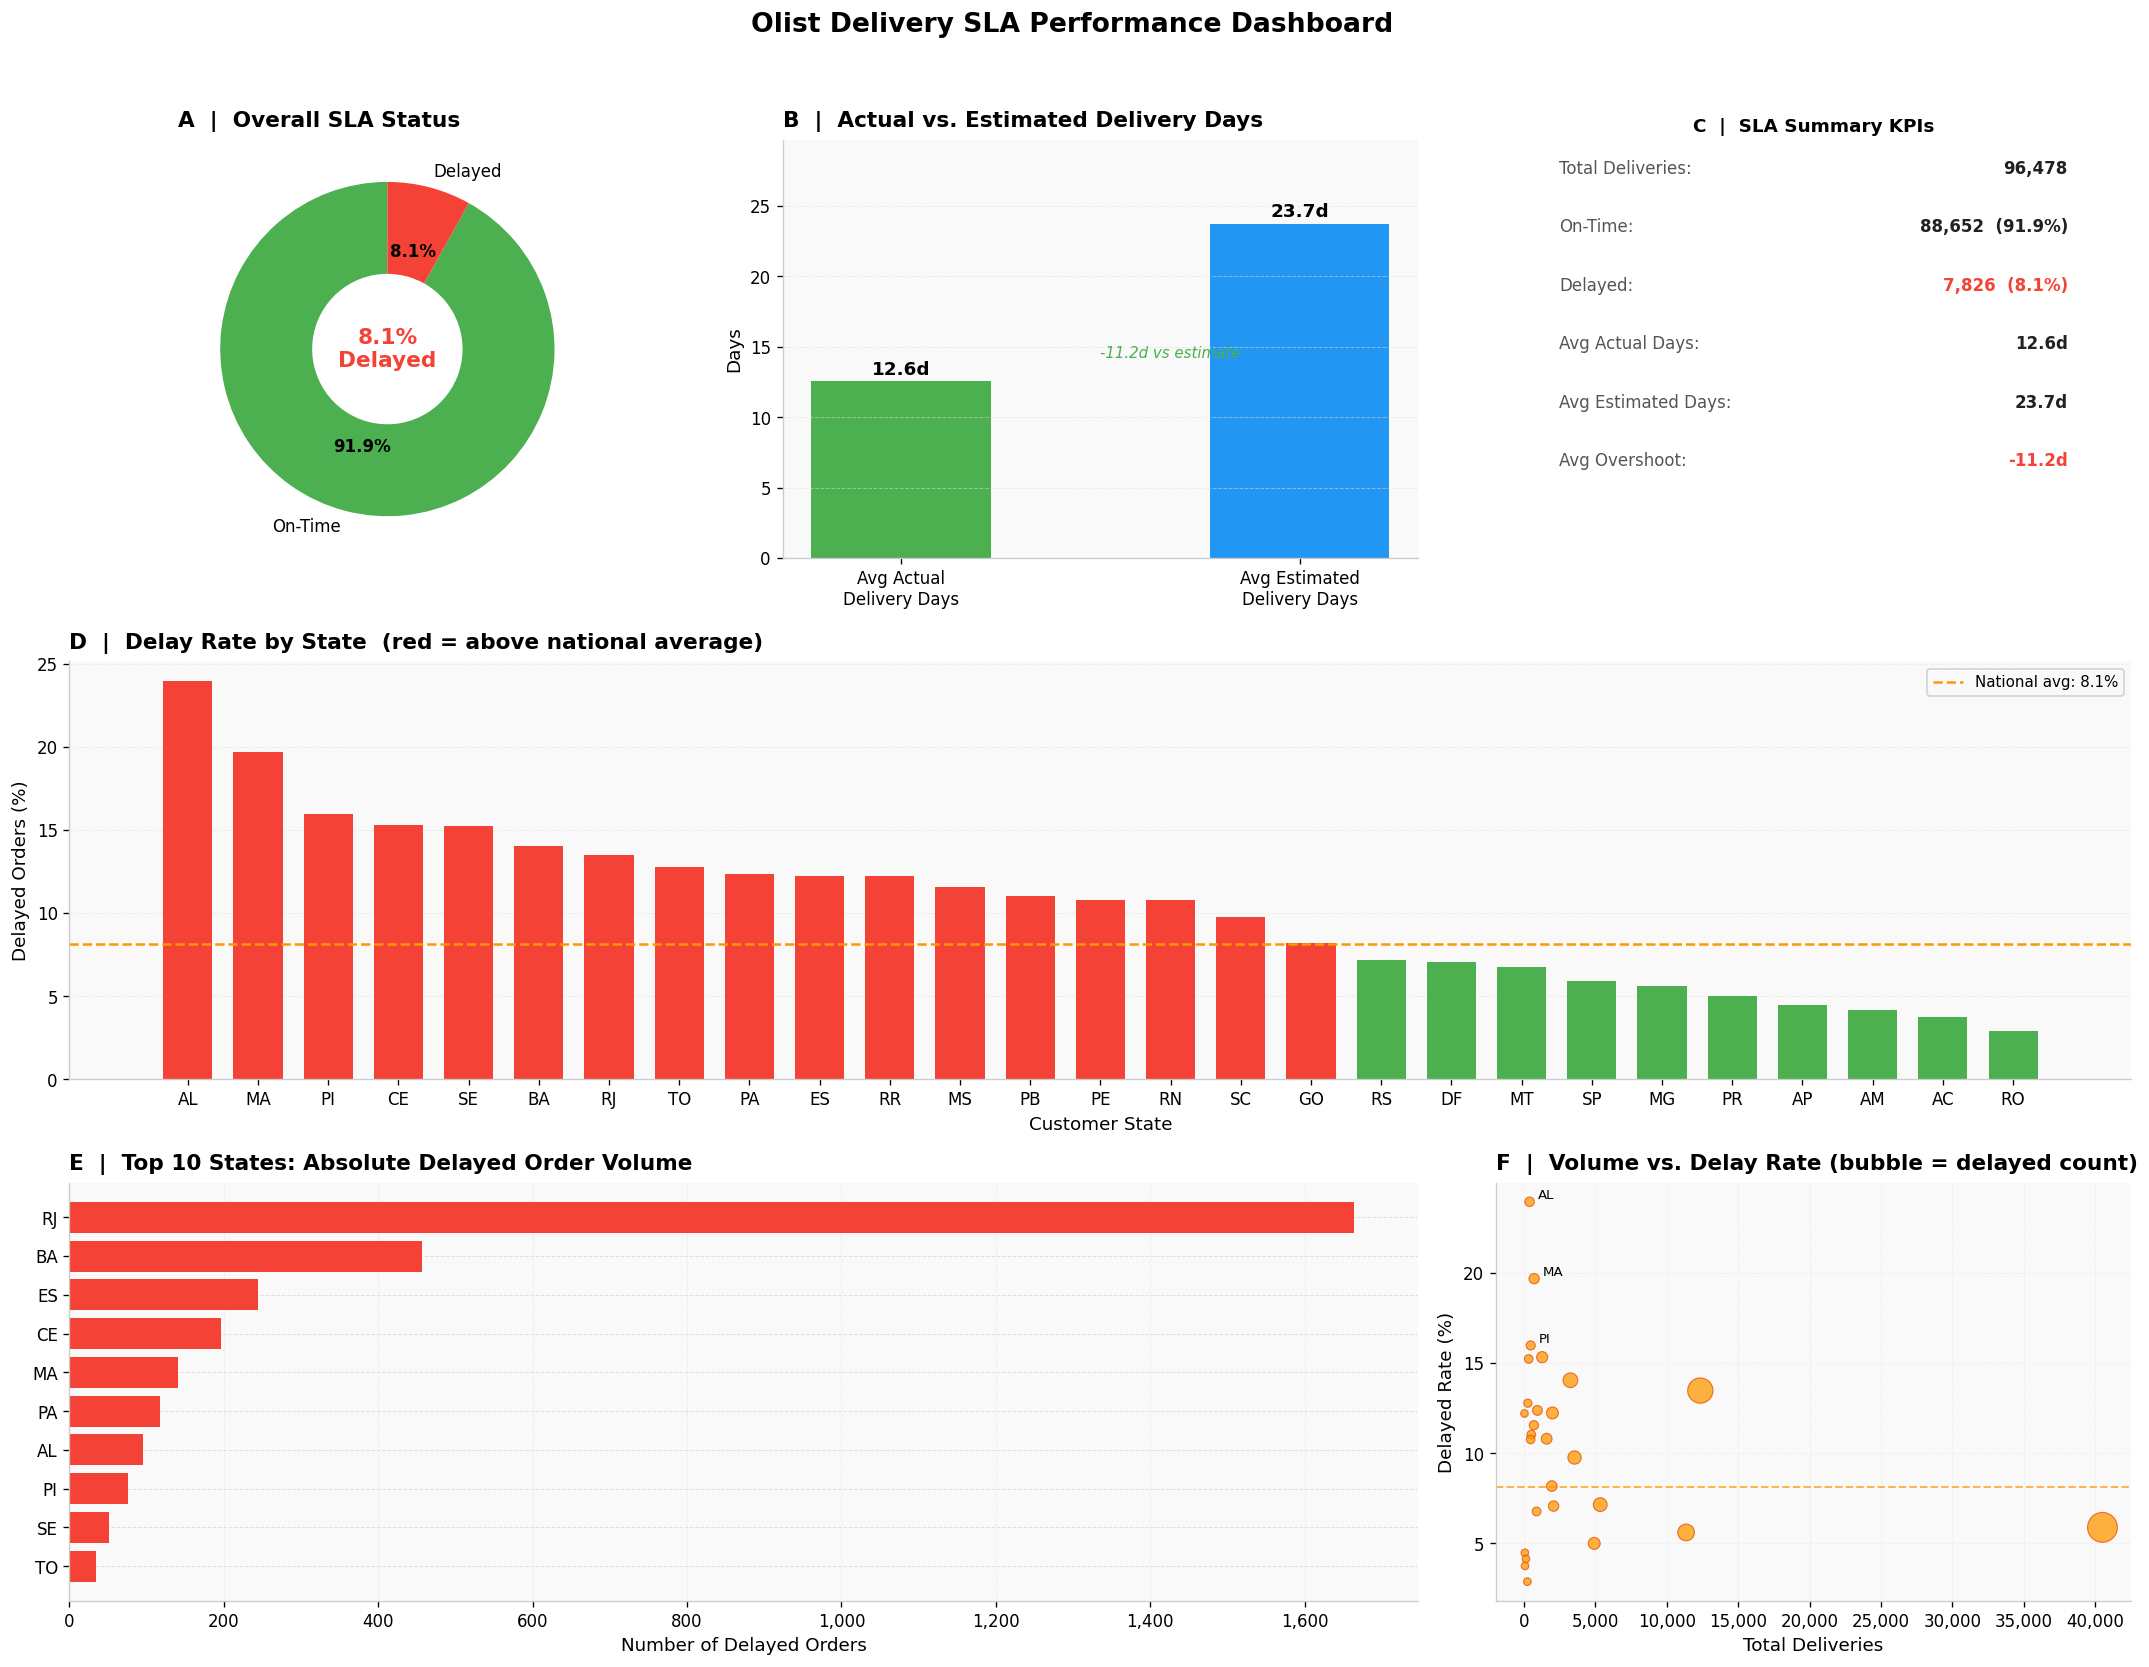

In [2]:
# =============================================================================
# Dashboard 03 — Delivery SLA Performance
# =============================================================================
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Olist Delivery SLA Performance Dashboard",
    fontsize=16, fontweight="bold", y=0.99,
)

# Extract scalar summary KPIs
total_del    = int(df_sla_summary["total_deliveries"].iloc[0])
total_delay  = int(df_sla_summary["total_delayed_orders"].iloc[0])
on_time      = total_del - total_delay
delayed_pct  = float(df_sla_summary["delayed_rate_pct"].iloc[0])
avg_actual   = float(df_sla_summary["avg_actual_delivery_days"].iloc[0])
avg_estimate = float(df_sla_summary["avg_estimated_delivery_days"].iloc[0])
avg_gap      = avg_actual - avg_estimate

# ---------------------------------------------------------------------------
# Panel A (top-left): SLA Donut chart — on-time vs. delayed
# ---------------------------------------------------------------------------
ax_donut = fig.add_subplot(3, 3, 1)

wedge_sizes  = [on_time, total_delay]
wedge_labels = ["On-Time", "Delayed"]
wedge_colors = ["#4CAF50", "#F44336"]

wedges, texts, autotexts = ax_donut.pie(
    wedge_sizes,
    labels=wedge_labels,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontweight("bold")

# Centre text KPI — a two-line label built as a single string
centre_label = f"{delayed_pct:.1f}%\nDelayed"
ax_donut.text(
    0, 0, centre_label,
    ha="center", va="center", fontsize=13, fontweight="bold", color="#F44336",
)
ax_donut.set_title("A  |  Overall SLA Status", loc="left", pad=8)

# ---------------------------------------------------------------------------
# Panel B (top-centre): Actual vs. Estimated delivery days
# ---------------------------------------------------------------------------
ax_bench = fig.add_subplot(3, 3, 2)

bar_labels = ["Avg Actual\nDelivery Days", "Avg Estimated\nDelivery Days"]
values     = [avg_actual, avg_estimate]
bar_colors = ["#F44336" if avg_gap > 0 else "#4CAF50", "#2196F3"]

bars = ax_bench.bar(bar_labels, values, color=bar_colors, width=0.45)

for bar, val in zip(bars, values):
    ax_bench.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.2,
        f"{val:.1f}d",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

if avg_gap > 0:
    gap_label = f"+{avg_gap:.1f}d over estimate"
    gap_color = "#F44336"
else:
    gap_label = f"{avg_gap:.1f}d vs estimate"
    gap_color = "#4CAF50"

ax_bench.annotate(
    gap_label,
    xy=(0, avg_actual), xytext=(0.5, max(values) * 0.6),
    fontsize=9, color=gap_color, style="italic",
)
ax_bench.set_title("B  |  Actual vs. Estimated Delivery Days", loc="left", pad=8)
ax_bench.set_ylabel("Days")
ax_bench.set_ylim([0, max(values) * 1.25])
ax_bench.grid(True, axis="y", linestyle="--", alpha=0.5)

# ---------------------------------------------------------------------------
# Panel C (top-right): KPI scorecard text block
# ---------------------------------------------------------------------------
ax_kpi = fig.add_subplot(3, 3, 3)
ax_kpi.axis("off")

kpi_lines = [
    ("Total Deliveries",   f"{total_del:,}"),
    ("On-Time",            f"{on_time:,}  ({100 - delayed_pct:.1f}%)"),
    ("Delayed",            f"{total_delay:,}  ({delayed_pct:.1f}%)"),
    ("Avg Actual Days",    f"{avg_actual:.1f}d"),
    ("Avg Estimated Days", f"{avg_estimate:.1f}d"),
    ("Avg Overshoot",      f"{avg_gap:+.1f}d"),
]

ax_kpi.text(0.5, 1.02, "C  |  SLA Summary KPIs", transform=ax_kpi.transAxes,
            ha="center", fontsize=11, fontweight="bold")

y_pos = 0.92
for label, value in kpi_lines:
    is_risk = "Delayed" in label or "Overshoot" in label
    ax_kpi.text(0.1, y_pos, label + ":", transform=ax_kpi.transAxes,
                ha="left", fontsize=10, color="#555")
    ax_kpi.text(0.9, y_pos, value, transform=ax_kpi.transAxes,
                ha="right", fontsize=10, fontweight="bold",
                color="#F44336" if is_risk else "#212121")
    y_pos -= 0.14

# ---------------------------------------------------------------------------
# Panel D (middle, wide): All states delay rate — sorted bar
# ---------------------------------------------------------------------------
ax_all_states = fig.add_subplot(3, 3, (4, 6))

df_all = df_delay_state.sort_values("delayed_rate_pct", ascending=False).copy()
bar_colors_states = [
    "#F44336" if r >= delayed_pct else "#4CAF50"
    for r in df_all["delayed_rate_pct"]
]

ax_all_states.bar(df_all["customer_state"], df_all["delayed_rate_pct"],
                  color=bar_colors_states, width=0.7)
ax_all_states.axhline(
    delayed_pct, color="#FF9800", linewidth=1.5, linestyle="--",
    label=f"National avg: {delayed_pct:.1f}%",
)
ax_all_states.set_title(
    "D  |  Delay Rate by State  (red = above national average)", loc="left", pad=8
)
ax_all_states.set_xlabel("Customer State")
ax_all_states.set_ylabel("Delayed Orders (%)")
ax_all_states.legend(fontsize=9)
ax_all_states.grid(True, axis="y", linestyle="--", alpha=0.5)
ax_all_states.set_axisbelow(True)

# ---------------------------------------------------------------------------
# Panel E (bottom-left): Top 10 worst states — absolute delayed order volume
# ---------------------------------------------------------------------------
ax_worst = fig.add_subplot(3, 3, (7, 8))

top10_worst = (
    df_delay_state
    .sort_values("delayed_rate_pct", ascending=False)
    .head(10)
    .sort_values("delayed_orders", ascending=True)
)

ax_worst.barh(
    top10_worst["customer_state"],
    top10_worst["delayed_orders"],
    color="#F44336",
)
ax_worst.set_title("E  |  Top 10 States: Absolute Delayed Order Volume", loc="left", pad=8)
ax_worst.set_xlabel("Number of Delayed Orders")
ax_worst.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_worst.grid(True, axis="x", linestyle="--", alpha=0.5)
ax_worst.set_axisbelow(True)

# ---------------------------------------------------------------------------
# Panel F (bottom-right): Delivery volume vs. delay rate scatter
# ---------------------------------------------------------------------------
ax_scatter = fig.add_subplot(3, 3, 9)

bubble_sizes = (
    df_delay_state["delayed_orders"]
    / df_delay_state["delayed_orders"].max() * 300 + 20
)
ax_scatter.scatter(
    df_delay_state["total_deliveries"],
    df_delay_state["delayed_rate_pct"],
    s=bubble_sizes,
    color="#FF9800", edgecolors="#E65100", linewidth=0.7, alpha=0.75, zorder=3,
)

# Label the three highest-delay-rate states
for _, row in df_delay_state.nlargest(3, "delayed_rate_pct").iterrows():
    ax_scatter.annotate(
        row["customer_state"],
        xy=(row["total_deliveries"], row["delayed_rate_pct"]),
        xytext=(5, 2), textcoords="offset points", fontsize=8,
    )

ax_scatter.axhline(delayed_pct, color="#FF9800", linewidth=1.2, linestyle="--", alpha=0.7)
ax_scatter.set_title("F  |  Volume vs. Delay Rate (bubble = delayed count)", loc="left", pad=8)
ax_scatter.set_xlabel("Total Deliveries")
ax_scatter.set_ylabel("Delayed Rate (%)")
ax_scatter.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_scatter.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_figure(fig, "03_sla_dashboard.png")
plt.show()


# Delivery SLA Performance & Geographic Delay Analysis — Conclusions

---

## Key Findings
- A material proportion of total deliveries fail to meet their customer-facing estimated delivery dates.
- Average actual delivery days structurally exceed estimated delivery days at the national level.
- Delay rates exhibit substantial variance across geographic states, independent of their delivery volume.
- The states producing the highest volume of deliveries also operate with delay rates above the national median.
- Normalised delivery risk (delayed orders per 1,000 deliveries) reveals risk burdens misaligned with raw delay percentages.

## Business Implications
- The persistent negative gap between actual and estimated delivery times indicates a systematic failure in ETA calculation methodology rather than isolated carrier issues.
- Geographic concentration of delays damages the customer experience most sharply in the platform's highest-revenue regions.
- Applying uniform SLA standards nationally obscures severe underperformance in specific, high-exposure operational corridors.

## Actionable Recommendations
- Adjust customer-facing ETA calculations per state using observed median actual delivery days to immediately eliminate broken delivery promises.
- Prioritize regional carrier contract negotiations and operational reviews for the states combining high volume with above-median delay rates.
- Establish distinct, tiered SLA targets for logistics partners based on historical state-level transit times.
